# Systematic Portfolio Research Foundation

## TL;DR

- This notebook consolidates the complete research foundation built so far: ingestion, quality control, normalization, temporal isolation, EDA, feature engineering, diagnostics, preprocessing, labels, and portfolio-readiness controls.
- The working development universe contains **5 instruments**. **ESU6, GCU6** are holdout-only and excluded from development; 6J is quarantined because its close series is constant at 0.01.
- Development ends **2025-08-15**. The sealed sequential holdout begins **2025-08-21** and is never loaded here.
- The library contains **116 engineered features**, with **113 retained** after removing two exact duplicate calculations and one cross-instrument-degenerate measure.
- Point-in-time preprocessing produces **2,473 complete model rows**; labels remain physically separate.
- The largest observed intraday coverage gap is **ZTU6 at 209.9 missing minutes per session on average**.
- No strategy or portfolio backtest has been run. Continuation-series roll/adjustment methodology remains the primary data-lineage blocker.


## Context & Methods

The objective is an institutional-style, reproducible research base for multi-asset futures, FX, and crypto. The intended research grain is one symbol-session row derived from gap-aware one-minute OHLCV bars. This foundation notebook is deliberately separate from the future portfolio-design notebook so data assumptions and controls remain stable while strategies evolve.

### Key Assumptions

- Source files are Investor/RT tabular exports interpreted in America/New_York time with an 18:00 futures-session boundary.
- Raw source files are read-only and identified by hashes.
- Missing minutes are not forward-filled and returns do not cross gaps or sessions.
- Features are usable only after their recorded availability timestamp.
- Preprocessing statistics use prior observations only.
- Correlated instruments are retained intentionally; only redundant calculations are excluded.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "data").exists(): ROOT = ROOT.parent
CATALOG = ROOT / "data/catalog"
OUT = ROOT / "outputs"
split = json.loads((CATALOG / "temporal_split.json").read_text())
manifest = pd.read_csv(CATALOG / "manifest.csv")
issues = pd.read_csv(CATALOG / "issues.csv")
coverage = pd.read_csv(CATALOG / "temporal_split_coverage.csv")
panel_quality = pd.read_csv(CATALOG / "panel_quality.csv")
instrument_quality = pd.read_csv(OUT / "instrument_quality_profile.csv")
feature_profile = pd.read_csv(OUT / "feature_quality_profile.csv")
redundancy = pd.read_csv(OUT / "feature_redundancy_pairs.csv")
drift = pd.read_csv(OUT / "feature_drift_profile.csv")
registry = pd.read_csv(CATALOG / "feature_registry.csv")
folds = pd.read_csv(CATALOG / "development_walk_forward_folds.csv")
features = pd.read_parquet(ROOT / "data/processed/features/development_session_features.parquet")
model_features = pd.read_parquet(ROOT / "data/processed/model_inputs/development_model_features.parquet")
labels = pd.read_parquet(ROOT / "data/processed/labels/development_forward_labels.parquet")
development = pd.read_parquet(ROOT / "data/processed/research/development_session_panel.parquet")
assert pd.to_datetime(development["trading_date"]).max() <= pd.Timestamp(split["development_end"])
assert not any("target" in c or "forward" in c for c in model_features.columns)
print("Development-only boundary verified. Sealed holdout was not loaded.")

Development-only boundary verified. Sealed holdout was not loaded.


## 1. Reproducible workspace and source lineage

In [2]:
print("Python environment: project-local .venv, Python 3.12")
print("Raw source policy: read-only")
manifest[["file", "path", "sha256"]]

Python environment: project-local .venv, Python 3.12
Raw source policy: read-only


,file,path,sha256
0,6JU6_Export.csv,C:\Users\JOSHD\Downloads\Market Data\6JU6_Expo...,73dd4ac1f7739734f7fff752495f0a3b0c3dbe7a8b3fbc...
1,CLU6_Export.csv,C:\Users\JOSHD\Downloads\Market Data\CLU6_Expo...,3e5332b5380ff979034219840598b7d1077b08cff9bb5e...
2,ESU6_Export.csv,C:\Users\JOSHD\Downloads\Market Data\ESU6_Expo...,c33903a274e11fe184e8c9a0a01030324770af47a490e2...
3,GCU6_Export.csv,C:\Users\JOSHD\Downloads\Market Data\GCU6_Expo...,397e2b2c93a52af4e8bdfd9895d2e27f7a426d4e3603e0...
4,HGU6_Export.csv,C:\Users\JOSHD\Downloads\Market Data\HGU6_Expo...,b9a2756737610187af69b9ed1c0e398052ecdc9ac15643...
5,NQU6_Export.csv,C:\Users\JOSHD\Downloads\Market Data\NQU6_Expo...,f68557c84b7c5e27b8161700ebe5af2b059f3dd4922bc7...
6,ZNU6_Export.csv,C:\Users\JOSHD\Downloads\Market Data\ZNU6_Expo...,c00ade45fca1c6a3d9305a1591cc7f0f24837fc8949f8e...
7,ZTU6_Export.csv,C:\Users\JOSHD\Downloads\Market Data\ZTU6_Expo...,6012c2f3467212a1c7ae490bf4f2fcce20baed1a8d13f3...


## 2. Source-data inventory and confirmed quality issues

In [3]:
issues.sort_values(["severity", "code"])[
    ["severity", "code", "file", "symbol", "message"]
]

,severity,code,file,symbol,message
0,high,constant_price_series,6JU6_Export.csv,6JU6,The entire close-price series is constant and ...
1,medium,open_interest_unavailable,6JU6_Export.csv,6JU6,Open interest is always zero; treat it as unav...
2,medium,open_interest_unavailable,CLU6_Export.csv,CLU6,Open interest is always zero; treat it as unav...
3,medium,open_interest_unavailable,ESU6_Export.csv,ESU6,Open interest is always zero; treat it as unav...
4,medium,open_interest_unavailable,GCU6_Export.csv,GCU6,Open interest is always zero; treat it as unav...
6,medium,open_interest_unavailable,HGU6_Export.csv,HGU6,Open interest is always zero; treat it as unav...
7,medium,open_interest_unavailable,NQU6_Export.csv,NQU6,Open interest is always zero; treat it as unav...
8,medium,open_interest_unavailable,ZNU6_Export.csv,ZNU6,Open interest is always zero; treat it as unav...
9,medium,open_interest_unavailable,ZTU6_Export.csv,ZTU6,Open interest is always zero; treat it as unav...
5,medium,short_history,GCU6_Export.csv,GCU6,Less than 30 calendar days of history.


The 6J file is quarantined, not repaired or silently substituted. Open interest is unavailable in the current exports and cannot be used for roll confirmation. GC has only one available session. The deleted NQ tick file is not part of the current manifest or processing pipeline.


## 3. Canonical one-minute processing preserves gaps

In [4]:
panel_quality.sort_values("symbol")

,symbol,minute_rows,sessions,first_timestamp_utc,last_timestamp_utc,duplicate_keys,gap_events,missing_minutes_inside_sessions,one_minute_return_coverage_pct
0,CLU6,1353404,995,2022-10-11T22:22:00+00:00,2026-08-20T20:53:00+00:00,0,11538,14294,99.0740
1,ESU6,172745,129,2026-02-20T04:37:00+00:00,2026-08-19T00:59:00+00:00,0,104,1518,99.8651
2,GCU6,1380,1,2026-08-19T22:01:00+00:00,2026-08-20T21:00:00+00:00,0,0,0,99.9275
3,HGU6,1292944,995,2022-10-11T22:22:00+00:00,2026-08-20T21:00:00+00:00,0,50788,74692,95.9950
4,NQU6,1344763,998,2022-10-12T03:37:00+00:00,2026-08-20T22:09:00+00:00,0,935,12333,99.8563
5,ZNU6,1277027,997,2022-10-11T22:22:00+00:00,2026-08-20T21:00:00+00:00,0,61265,90062,95.1245
6,ZTU6,1140672,997,2022-10-11T22:23:00+00:00,2026-08-20T21:00:00+00:00,0,121114,226388,89.2948


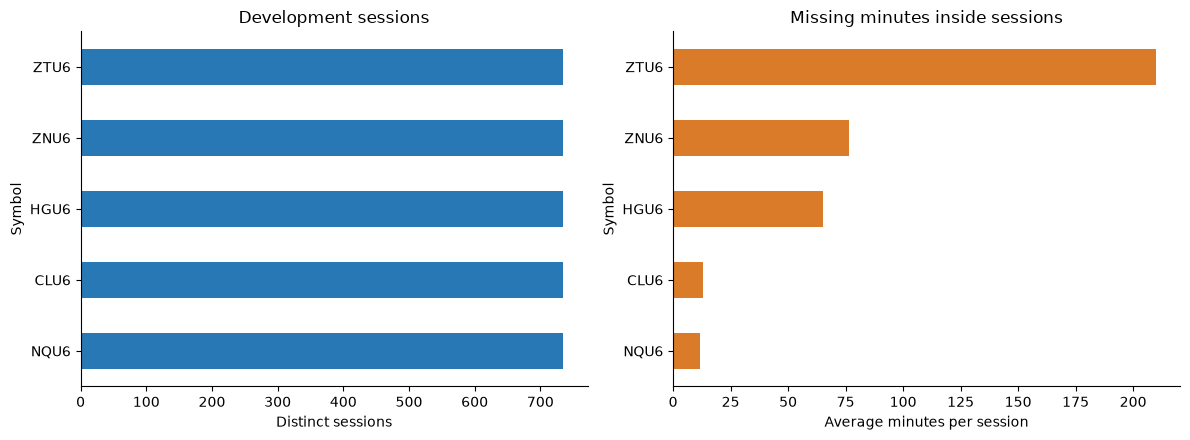

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
quality = instrument_quality.sort_values("missing_minutes_per_session")
quality.plot.barh(x="symbol", y="sessions", ax=axes[0], color="#2878B5", legend=False)
quality.plot.barh(x="symbol", y="missing_minutes_per_session", ax=axes[1], color="#D97B29", legend=False)
axes[0].set(title="Development sessions", xlabel="Distinct sessions", ylabel="Symbol")
axes[1].set(title="Missing minutes inside sessions", xlabel="Average minutes per session", ylabel="Symbol")
for ax in axes: ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); plt.show()

## 4. Temporal isolation protects the sequential holdout

In [6]:
print(json.dumps(split, indent=2))
coverage

{
  "latest_session": "2026-08-21",
  "development_end": "2025-08-15",
  "holdout_start": "2025-08-21",
  "holdout_months": 12,
  "embargo_days": 5
}


,symbol,first_session,last_session,development_sessions,holdout_sessions,eligibility
0,CLU6,2022-10-12,2026-08-20,734,258,development_and_holdout
1,ESU6,2026-02-20,2026-08-19,0,129,holdout_only
2,GCU6,2026-08-20,2026-08-20,0,1,holdout_only
3,HGU6,2022-10-12,2026-08-20,734,258,development_and_holdout
4,NQU6,2022-10-12,2026-08-21,735,260,development_and_holdout
5,ZNU6,2022-10-12,2026-08-20,735,259,development_and_holdout
6,ZTU6,2022-10-12,2026-08-20,735,259,development_and_holdout


Development, embargo, and sealed-holdout observations are stored separately. ES and GC currently have no development observations, so they cannot influence feature choices or portfolio design until older history is supplied.


## 5. Development-market behavior and diversification structure

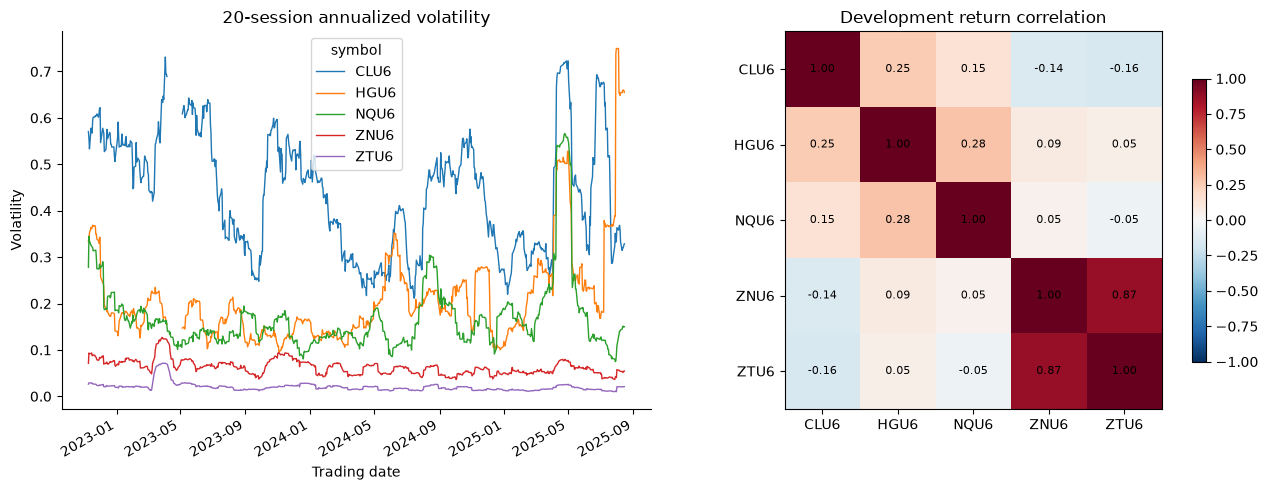

In [7]:
development["trading_date"] = pd.to_datetime(development["trading_date"])
returns = development.pivot(index="trading_date", columns="symbol", values="close_to_close_return")
corr = returns.corr(min_periods=60)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
rolling_vol = returns.rolling(20, min_periods=20).std() * np.sqrt(252)
rolling_vol.plot(ax=axes[0], linewidth=1)
axes[0].set(title="20-session annualized volatility", xlabel="Trading date", ylabel="Volatility")
image = axes[1].imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
axes[1].set_xticks(range(len(corr)), corr.columns)
axes[1].set_yticks(range(len(corr)), corr.index)
for row in range(len(corr)):
    for col in range(len(corr)):
        axes[1].text(col, row, f"{corr.iloc[row, col]:.2f}", ha="center", va="center", fontsize=8)
axes[1].set_title("Development return correlation")
fig.colorbar(image, ax=axes[1], shrink=.75)
axes[0].spines[["top", "right"]].set_visible(False)
fig.tight_layout(); plt.show()

## 6. Feature library covers complementary research hypotheses

In [8]:
family_counts = registry.groupby("family").agg(total=("feature", "size"), selected=("selected", "sum"))
family_counts.sort_values("selected", ascending=False)

,total,selected
family,,
ohlcv_history,19,18
volatility_liquidity_regime,18,18
range_atr_and_estimators,15,15
minute_bar_pace_and_distribution,12,11
momentum_reversal,12,11
moving_average_structure,10,10
trend,9,9
linear_regression_structure,8,8
intraday_realized_risk,7,7


The feature families cover momentum/reversal, trend, volatility and liquidity regimes, cross-market lead/lag, ATR and range estimators, OHLCV history, moving-average structure, regression structure, minute-bar pace proxies, and realized intraday risk. Implied volatility and true tick pace remain unavailable because the source lacks options and trade-level data.


## 7. Feature diagnostics distinguish warm-up, redundancy, and drift

In [9]:
diagnostic_summary = pd.DataFrame({
    "check": ["Features", "Mature missingness >1%", "Constant features", "|correlation| >= 0.95 pairs", "Median drift >1 pooled IQR"],
    "result": [len(feature_profile), (feature_profile.missing_pct_after_warmup > 1).sum(), (feature_profile.distinct_values <= 1).sum(), len(redundancy), (drift.median_shift_in_iqr > 1).sum()],
})
diagnostic_summary

,check,result
0,Features,116
1,Mature missingness >1%,0
2,Constant features,0
3,|correlation| >= 0.95 pairs,76
4,Median drift >1 pooled IQR,0


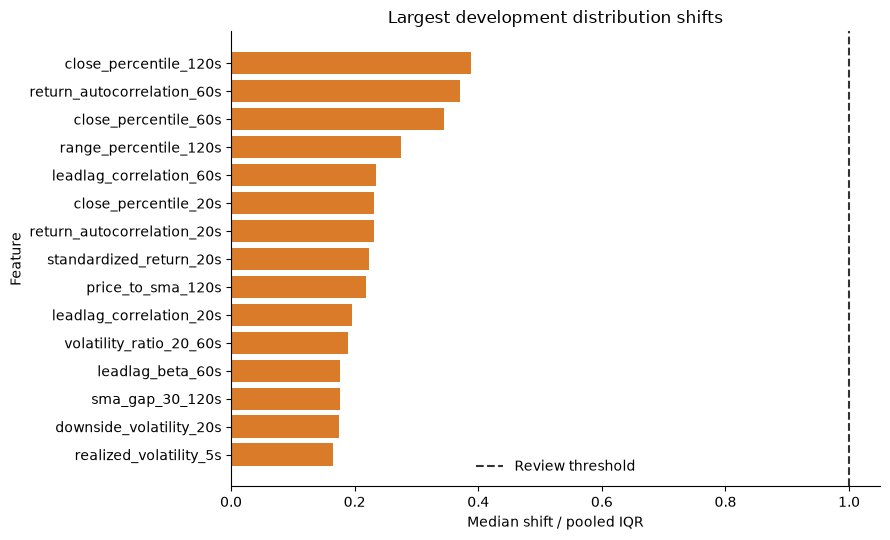

In [10]:
top_drift = drift.dropna(subset=["median_shift_in_iqr"]).head(15).sort_values("median_shift_in_iqr")
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(top_drift["feature"], top_drift["median_shift_in_iqr"], color="#D97B29")
ax.axvline(1, color="#333333", linestyle="--", label="Review threshold")
ax.set(title="Largest development distribution shifts", xlabel="Median shift / pooled IQR", ylabel="Feature")
ax.legend(frameon=False); ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); plt.show()

## 8. Feature registry removes calculations—not correlated instruments

In [11]:
registry.loc[~registry["selected"], ["feature", "family", "status", "duplicate_of", "note"]]

,feature,family,status,duplicate_of,note
10,reversal_1s,momentum_reversal,drop_exact_duplicate,log_return_1s,Exact algebraic duplicate; retain the named re...
60,open_to_previous_close,ohlcv_history,drop_exact_duplicate,overnight_gap_fraction,Exact algebraic duplicate; retain the named re...
104,intraday_return_median,minute_bar_pace_and_distribution,drop_cross_instrument_degenerate,return_sign_imbalance,Degenerate for one or more instruments; retain...


Correlated and inversely correlated instruments remain in the universe for spreads, relative value, lead/lag, residual momentum, dynamic hedging, and changing-correlation regimes. High correlation among feature columns is reviewed separately to avoid counting the same calculation repeatedly.


## 9. Point-in-time preprocessing is causal

In [12]:
preprocessing = json.loads((CATALOG / "preprocessing_summary.json").read_text())
print(json.dumps(preprocessing, indent=2))
model_features.groupby("symbol")["model_row_complete"].agg(["sum", "count"])

{
  "input_features": 116,
  "selected_features": 113,
  "dropped_exact_duplicates": {
    "reversal_1s": "log_return_1s",
    "open_to_previous_close": "overnight_gap_fraction"
  },
  "dropped_cross_instrument_degenerate": {
    "intraday_return_median": "return_sign_imbalance"
  },
  "mature_complete_rows": 2473,
  "preprocessing": {
    "minimum_history_sessions": 120,
    "winsorization": {
      "lower_quantile": 0.01,
      "upper_quantile": 0.99,
      "point_in_time": true
    },
    "scaling": {
      "method": "expanding_median_iqr",
      "point_in_time": true
    },
    "missing_values": {
      "warmup": "exclude_row_until_available",
      "mature_period": "no_imputation"
    },
    "redundancy": {
      "exact_feature_drops": {
        "reversal_1s": "log_return_1s",
        "open_to_previous_close": "overnight_gap_fraction"
      },
      "cross_instrument_degenerate_drops": {
        "intraday_return_median": "return_sign_imbalance"
      },
      "review_absolute_corr

,sum,count
symbol,,
CLU6,494,734
HGU6,494,734
NQU6,495,735
ZNU6,495,735
ZTU6,495,735


Each instrument uses expanding 1st/99th-percentile winsorization and median/IQR scaling based strictly on earlier observations. Warm-up rows are excluded, and mature missing values are not silently imputed.


## 10. Forward labels remain physically separate

In [13]:
label_columns = [column for column in labels if column.startswith("forward_log_return")]
labels.groupby("symbol")[label_columns].count()

,forward_log_return_1s,forward_log_return_5s,forward_log_return_20s
symbol,,,
CLU6,733,729,714
HGU6,733,729,714
NQU6,734,730,715
ZNU6,734,730,715
ZTU6,734,730,715


The 1-, 5-, and 20-session forward log returns are research labels only. They are never stored in the model feature matrix, and each carries the future timestamp at which it becomes observable.


## 11. Walk-forward protocol is frozen before strategy work

In [14]:
folds

,fold,train_start,train_end,embargo_start,embargo_end,validation_start,validation_end,train_sessions,validation_sessions
0,1,2022-10-12,2024-09-23,2024-09-24,2024-09-30,2024-10-01,2024-12-27,504,63
1,2,2022-10-12,2024-12-19,2024-12-20,2024-12-27,2024-12-30,2025-03-27,567,63
2,3,2022-10-12,2025-03-20,2025-03-21,2025-03-27,2025-03-28,2025-06-25,630,63
3,4,2022-10-12,2025-06-18,2025-06-19,2025-06-25,2025-06-26,2025-08-15,693,37


## 12. Portfolio-readiness policy

In [15]:
portfolio = yaml.safe_load((ROOT / "config/portfolio.yaml").read_text())["portfolio_design"]
pd.json_normalize(portfolio, sep=".").T.rename(columns={0: "configured_value"})

,configured_value
status,design_only_no_backtest
direction,long_short
rebalance_frequency,daily
signal_lag_sessions,1
target_annualized_volatility,0.1
unavailable_until_more_data,"[ES, GC, 6J]"
covariance.method,exponentially_weighted
covariance.lookback_sessions,60
covariance.half_life_sessions,20
covariance.shrinkage,True


## Limitations and unresolved risks

- **Continuation construction:** Investor/RT roll dates and price-adjustment method are not confirmed. This can materially change long-horizon returns and P&L.
- **Tradability inputs:** commissions, bid/ask spreads, slippage, roll costs, and liquidity limits still require calibration.
- **Universe gaps:** older ES and GC development data are required; 6J requires replacement with a valid series.
- **Unavailable data:** open interest, options/implied volatility, trade counts, bid/ask, and order-book data are absent.
- **Session gaps:** ZT, ZN, and HG have materially more missing minutes than CL and NQ; strategy rules must not treat those gaps as zero returns.
- **No performance claim:** feature completeness and stability do not establish predictive value.


## Takeaways and handoff to portfolio design

The research foundation is internally consistent, reproducible, point-in-time, and protected from the sealed holdout. The next notebook should be a separate portfolio-design laboratory. It should begin with explicit signal sleeves—trend, reversal, relative momentum, lead/lag, correlation divergence, and volatility regime—then define forecast combination, risk allocation, contract sizing, and execution assumptions. Strategy evaluation should use only the four predefined development folds until the complete design is frozen.
